/tmp/ipykernel_13540/3568067651.py:5: RuntimeWarning: overflow encountered in scalar multiply
  return -1000 * y + 3000 - 2000 * np.exp(-t)
/tmp/ipykernel_13540/3568067651.py:20: RuntimeWarning: invalid value encountered in scalar add
  y[i+1] = y[i] + h * f(t[i], y[i])


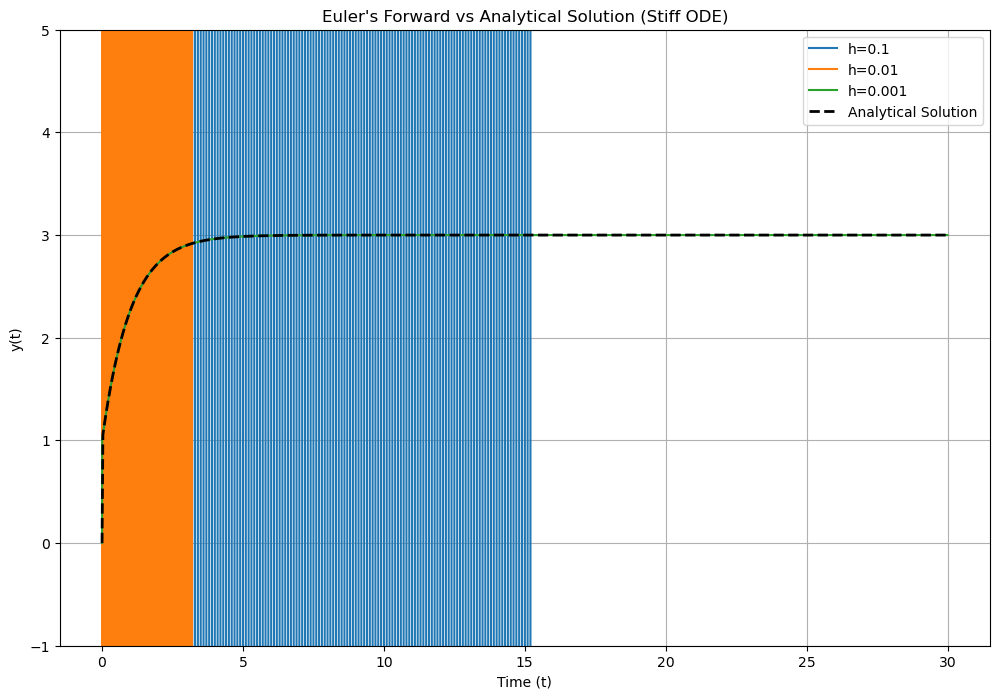

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def f(t, y):
    return -1000 * y + 3000 - 2000 * np.exp(-t)
def analytical(t):
    return 3 - 0.998 * np.exp(-1000 * t) - 2.002 * np.exp(-t)

ti = 0
tf = 30
y0 = 0
h_values = np.array([0.1, 0.01, 0.001])
plt.figure(figsize=(12, 8))

for h in h_values:
    t = np.arange(ti, tf + h, h)
    y = np.zeros(len(t))
    y[0] = y0
    for i in range(len(t) - 1):
        y[i+1] = y[i] + h * f(t[i], y[i])
    plt.plot(t, y, label=f'h={h}')

exactTime = np.linspace(ti, tf, 1000)
plt.plot(exactTime, analytical(exactTime), 'k--', linewidth=2, label='Analytical Solution')
plt.ylim(-1, 5)
plt.title("Euler's Forward vs Analytical Solution (Stiff ODE)")
plt.xlabel("Time (t)")
plt.ylabel("y(t)")
plt.legend()
plt.grid(True)
plt.show()

## h = 0.1 and h = 0.01 both wildly diverge as their values are too large. h = 0.001 is small enough that it satisfies the stability requirement of the Euler forward method (h = 0.002)